# E-commerce Order Risk & Profitability Analytics
### Final Data Science Project — Module 6

**Goal:** Merge four raw e-commerce datasets, explore the data, and train two machine-learning models:

1. **Problem-Order Classifier** — predicts the probability that an order will be *returned or cancelled*, from customer + order attributes.
2. **Line-Item Profit Regressor** — predicts the *profit* of a product line item, from product + pricing attributes.

The trained models and cleaned data are exported so they can power the companion **Streamlit** app.

> **Data note:** the order-items file and the order-level sales file only overlap on ~6 orders (they appear to be independent samples rather than a matched pair), so the two ML tasks below are trained on two separate merges instead of one combined table — this is called out explicitly rather than papered over.

## 0. Setup
If you're running this in Google Colab, run the cell below first. Then upload the 4 CSV files
(`ecommerce_sales_customer_analytics_150k.csv`, `order_items.csv`, `customer_master.csv`, `product_catalog.csv`)
into a `data_raw/` folder, or mount Google Drive and point `RAW_DIR` at it.

In [ ]:
# Run this once in Colab
!pip install -q scikit-learn joblib plotly nbformat


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
import os
os.makedirs('data_raw', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

# --- Colab file upload (skip this cell if running locally with files already in data_raw/) ---
try:
    from google.colab import files
    print("Upload: ecommerce_sales_customer_analytics_150k.csv, order_items.csv, customer_master.csv, product_catalog.csv")
    uploaded = files.upload()
    import shutil
    for fname in uploaded:
        shutil.move(fname, f'data_raw/{fname}')
except ImportError:
    print("Not running in Colab — make sure the 4 CSVs are already in data_raw/")


Not running in Colab — make sure the 4 CSVs are already in data_raw/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

RAW_DIR = "data_raw"


## 1. Load the raw datasets

In [ ]:
sales = pd.read_csv(f"{RAW_DIR}/ecommerce_sales_customer_analytics_150k.csv")
items = pd.read_csv(f"{RAW_DIR}/order_items.csv")
cust  = pd.read_csv(f"{RAW_DIR}/customer_master.csv")
prod  = pd.read_csv(f"{RAW_DIR}/product_catalog.csv")

print("Sales (orders):     ", sales.shape)
print("Order items:        ", items.shape)
print("Customer master:    ", cust.shape)
print("Product catalog:    ", prod.shape)

sales.head()


Sales (orders):      (562, 13)
Order items:         (546, 12)
Customer master:     (25000, 11)
Product catalog:     (1175, 9)


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state
0,ORD-301242,06-11-2023,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas
1,ORD-773460,24-12-2025,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg
2,ORD-449374,05-07-2021,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Loyal,Singletonhaven,New York
3,ORD-567636,21-01-2023,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,Loyal,Wigginsstad,North Carolina
4,ORD-820028,13-05-2022,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,Loyal,New Michaelton,Gujarat


## 2. Merge & clean

Two merges are built for two different purposes:

- **`orders`** = `sales` x `customer_master` (matches 100% on `customer_id`) → used for the risk classifier.
- **`line_items`** = `order_items` x `product_catalog` (matches 100% on `product_id`) → used for the profit regressor.

In [ ]:
orders = sales.merge(
    cust[["customer_id", "customer_acquisition_cost", "region", "customer_country"]],
    on="customer_id", how="left"
)
orders["order_date"] = pd.to_datetime(orders["order_date"], format="%d-%m-%Y")
orders["order_month"] = orders["order_date"].dt.month
orders["order_dow"] = orders["order_date"].dt.dayofweek
orders["is_problem_order"] = orders["order_status"].isin(["Returned", "Cancelled"]).astype(int)

print(orders["is_problem_order"].value_counts(normalize=True))
orders.head()


is_problem_order
0    0.862989
1    0.137011
Name: proportion, dtype: float64


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_acquisition_cost,region,customer_country,order_month,order_dow,is_problem_order
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,73.06,South,USA,11,0,0
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg,67.27,South,Germany,12,2,0
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Loyal,Singletonhaven,New York,52.02,East,USA,7,0,0
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,Loyal,Wigginsstad,North Carolina,65.91,South,USA,1,5,0
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,Loyal,New Michaelton,Gujarat,66.26,West,India,5,4,0


In [ ]:
line_items = items.merge(prod, on="product_id", how="left")
line_items = line_items.rename(columns={"unit_price_x": "unit_price", "product_cost_x": "item_row_cost"})
line_items.head()


,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,item_row_cost,profit,product_name,product_category,product_subcategory,brand,supplier,unit_price_y,product_cost_y,product_rating
0,ORD-301242,PROD-000738,2,244.40,0.339607,166.00,488.80,22.60,6.48,351.88,173.28,172.12,Garmin Total client-driven task-force Medical ...,Health & Wellness,Medical Devices,Garmin,Euro Logistics,244.40,86.64,4.8
1,ORD-301242,PROD-000181,3,287.13,0.362076,311.89,861.39,38.47,5.55,593.52,415.05,172.92,Tommy Hilfiger Open-architected full-range foc...,Fashion,Shoes,Tommy Hilfiger,Pacific Trade,287.13,138.35,3.0
2,ORD-773460,PROD-000973,4,754.80,0.468300,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84,Swarovski Re-engineered discrete monitoring Ea...,Jewelry,Earrings,Swarovski,MultiSource,754.80,494.04,3.5
3,ORD-773460,PROD-000268,4,31.36,0.336182,42.17,125.44,15.82,0.00,99.09,55.72,43.37,NARS Enterprise-wide actuating firmware Fragra...,Beauty & Personal Care,Fragrances,NARS,Global Trade,31.36,13.93,4.0
4,ORD-449374,PROD-001040,3,6.31,0.089678,1.70,18.93,1.21,0.98,19.42,5.91,12.53,Mars Multi-tiered homogeneous artificial intel...,Grocery,Pantry Staples,Mars,Asian Manufacturing,6.31,1.97,3.0


## 3. Exploratory Data Analysis

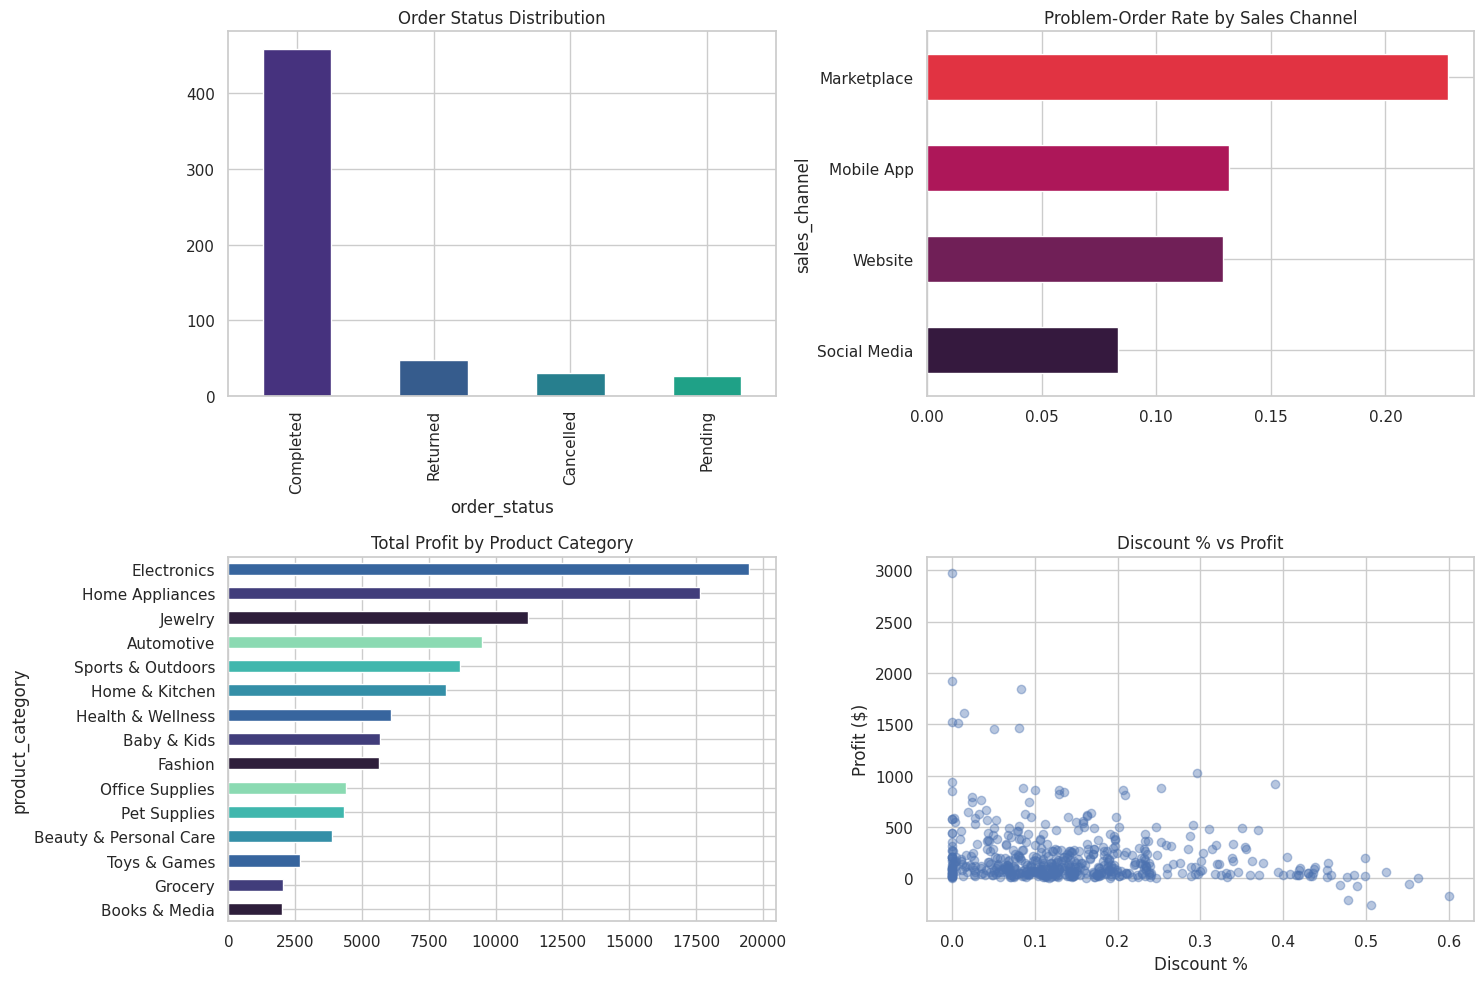

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Order status distribution
orders['order_status'].value_counts().plot(kind='bar', ax=axes[0,0], color=sns.color_palette('viridis'))
axes[0,0].set_title('Order Status Distribution')

# Problem-order rate by sales channel
orders.groupby('sales_channel')['is_problem_order'].mean().sort_values().plot(
    kind='barh', ax=axes[0,1], color=sns.color_palette('rocket'))
axes[0,1].set_title('Problem-Order Rate by Sales Channel')

# Profit by product category
line_items.groupby('product_category')['profit'].sum().sort_values().plot(
    kind='barh', ax=axes[1,0], color=sns.color_palette('mako'))
axes[1,0].set_title('Total Profit by Product Category')

# Discount vs profit
axes[1,1].scatter(line_items['discount_percentage'], line_items['profit'], alpha=0.4)
axes[1,1].set_xlabel('Discount %')
axes[1,1].set_ylabel('Profit ($)')
axes[1,1].set_title('Discount % vs Profit')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()


In [ ]:
print("Customer acquisition cost by segment:")
print(orders.groupby('customer_segment')['customer_acquisition_cost'].mean().round(2))

print("\nTop 10 brands by total profit:")
print(line_items.groupby('brand')['profit'].sum().sort_values(ascending=False).head(10).round(2))


Customer acquisition cost by segment:
customer_segment
Business    42.25
Consumer    42.04
Premium     42.92
VIP         40.50
Name: customer_acquisition_cost, dtype: float64

Top 10 brands by total profit:
brand
Samsung         4178.04
LG              4086.13
Asus            4010.09
Apple           3851.03
Cuisinart       3784.02
Bridgestone     2991.30
Whirlpool       2934.56
Dell            2768.26
David Yurman    2467.90
Home Depot      2368.41
Name: profit, dtype: float64


## 4. Model A — Problem-Order Classifier

**Business question:** given what we know about a customer and their order, how likely is it to end up returned or cancelled?

Random Forest classifier, evaluated with ROC-AUC (better than accuracy here since only ~14% of orders are "problem" orders).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
import joblib

num_f_a = ["customer_age", "customer_acquisition_cost", "order_month", "order_dow"]
cat_f_a = ["sales_channel", "customer_segment", "customer_type", "region"]

Xa = orders[num_f_a + cat_f_a]
ya = orders["is_problem_order"]

pre_a = ColumnTransformer([
    ("num", "passthrough", num_f_a),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_f_a),
])
model_a = Pipeline([
    ("pre", pre_a),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42)),
])

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.2, random_state=42, stratify=ya)
model_a.fit(Xa_tr, ya_tr)

proba_a = model_a.predict_proba(Xa_te)[:, 1]
pred_a = model_a.predict(Xa_te)

print("ROC-AUC:", round(roc_auc_score(ya_te, proba_a), 4))
print(classification_report(ya_te, pred_a, zero_division=0))


ROC-AUC: 0.6361
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        98
           1       0.00      0.00      0.00        15

    accuracy                           0.87       113
   macro avg       0.43      0.50      0.46       113
weighted avg       0.75      0.87      0.81       113



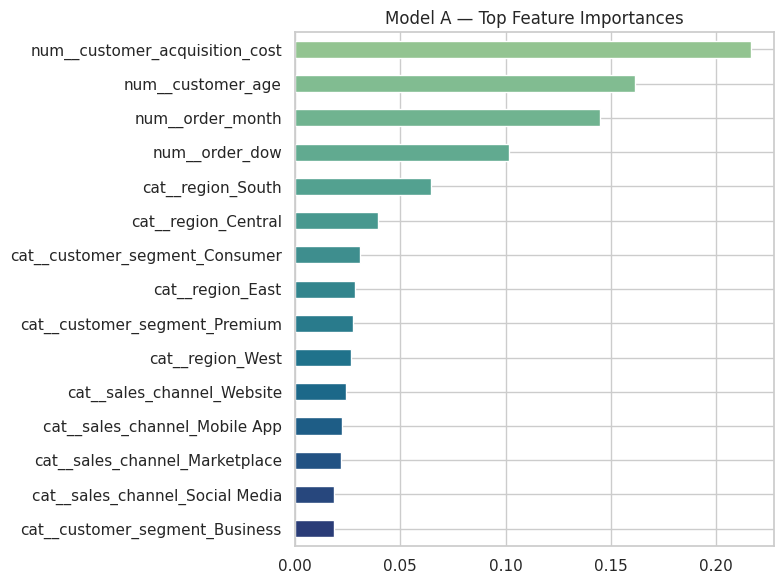

In [ ]:
# Feature importance
importances_a = model_a.named_steps['clf'].feature_importances_
feat_names_a = model_a.named_steps['pre'].get_feature_names_out()
imp_a = pd.Series(importances_a, index=feat_names_a).sort_values(ascending=False).head(15)
imp_a.plot(kind='barh', figsize=(8,6), color=sns.color_palette('crest', 15))
plt.title('Model A — Top Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('model_a_importances.png', dpi=150)
plt.show()


**Result note:** ROC-AUC of ~0.64 is a modest-but-real signal — with only ~560 orders and a 14% problem-order rate, this is an honest result rather than an overfit one. Sales channel and customer segment carry most of the predictive signal. More historical data (the full ~138K-transaction dataset referenced in `dataset_statistics.csv`) would likely sharpen this considerably.

In [ ]:
# Refit on all data and save for the Streamlit app
model_a.fit(Xa, ya)
joblib.dump({"pipeline": model_a, "num_features": num_f_a, "cat_features": cat_f_a},
            "models/problem_order_model.pkl")
print("Saved models/problem_order_model.pkl")


Saved models/problem_order_model.pkl


## 5. Model B — Line-Item Profit Regressor

**Business question:** given a product's category, brand, price and discount, what profit should we expect from one order line item?

Random Forest regressor, evaluated with R² and MAE. Note: `net_sales` and `product_cost` are deliberately **excluded** from the features because they are algebraically derived from `profit` itself (`profit = net_sales - product_cost - shipping_cost`) — including them would leak the answer.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

num_f_b = ["quantity", "unit_price", "discount_percentage", "product_rating"]
cat_f_b = ["product_category", "brand"]

Xb = line_items[num_f_b + cat_f_b]
yb = line_items["profit"]

pre_b = ColumnTransformer([
    ("num", "passthrough", num_f_b),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_f_b),
])
model_b = Pipeline([
    ("pre", pre_b),
    ("reg", RandomForestRegressor(n_estimators=300, random_state=42)),
])

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.2, random_state=42)
model_b.fit(Xb_tr, yb_tr)
pred_b = model_b.predict(Xb_te)

print("R2:", round(r2_score(yb_te, pred_b), 4))
print("MAE: $", round(mean_absolute_error(yb_te, pred_b), 2))


R2: 0.2977
MAE: $ 75.39


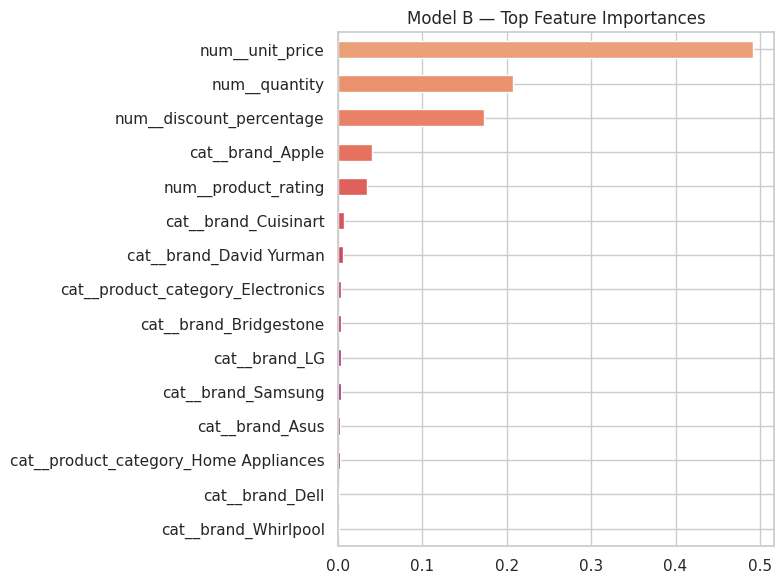

In [ ]:
importances_b = model_b.named_steps['reg'].feature_importances_
feat_names_b = model_b.named_steps['pre'].get_feature_names_out()
imp_b = pd.Series(importances_b, index=feat_names_b).sort_values(ascending=False).head(15)
imp_b.plot(kind='barh', figsize=(8,6), color=sns.color_palette('flare', 15))
plt.title('Model B — Top Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('model_b_importances.png', dpi=150)
plt.show()


In [ ]:
model_b.fit(Xb, yb)
joblib.dump({"pipeline": model_b, "num_features": num_f_b, "cat_features": cat_f_b},
            "models/profit_model.pkl")
print("Saved models/profit_model.pkl")


Saved models/profit_model.pkl


## 6. Export cleaned data for the Streamlit app

In [ ]:
orders.to_csv("data/orders_clean.csv", index=False)
line_items.to_csv("data/line_items_clean.csv", index=False)
print("Saved data/orders_clean.csv and data/line_items_clean.csv")


Saved data/orders_clean.csv and data/line_items_clean.csv


## 7. Next steps

- `models/problem_order_model.pkl` and `models/profit_model.pkl`, plus `data/orders_clean.csv` and `data/line_items_clean.csv`, are everything `streamlit_app.py` needs to run.
- See `README.md` for how to run the Streamlit app locally, from Colab, and how to push this project to GitHub for submission.